**Diana Itzel Soto Castañeda**

**Ciencia de Datos para Sensores Inteligentes**

Práctica 3 Predicción de tiros de baloncesto

# Imports

In [393]:
# system libraries
import os
import sys

print("Python:", sys.version)
print("Executable:", sys.executable)

Python: 3.9.25 (main, Nov  3 2025, 22:44:01) [MSC v.1929 64 bit (AMD64)]
Executable: c:\Users\Diana\git\Course_CDSI_2026\practicas\PR3_Inercial\.venv\python.exe


In [394]:
from pathlib import Path
from scipy.signal import find_peaks
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1.- Recolección de datos

Se recolectaron datos de tiros de baloncesto. Para ello se emplearon tres sensores IMU (*Inertial Measurement Unit*) modelo LPMS-B2 Series. Los sensores se colocaron en mano, antebrazo y brazo superior. En la prueba participarón ocho sujetos, cada uno tiro tantos tiros como necesitará antes de encestar tres o acompletar veinte tiros. Para cada tiro se etiqueto el éxito o fallo del tiro. Los sensores se calibrarón antes de iniciar la grabación con los brazos abajo.

Cabe resaltar que durante la recolección de los datos se detectarón múltiples fallas de pérdida de conexión con los sensores, por lo cuál no se cuenta con datos completos para cada tiro, como se había determinado. Además de que los datos de tiro exitoso fueron escasos en comparación con los datos de falla.

## Carga de datos

In [395]:
project_root = Path(".")
data_trial_dir = project_root / "data"
labels_path = data_trial_dir / "labels_PR3.csv"

data_test_dir = project_root / "data" / "test"

labels = pd.read_csv(labels_path)

# Cargar todos los archivos de datos de prueba
df_trial = {}
for idx, row in labels.iterrows():
    file_name = row["Nombre Archivo"]
    file_path = data_trial_dir / file_name

    # print(file_path)
    
    if file_path.exists():
        try:
            df_trial[file_name] = pd.read_csv(file_path)
        except pd.errors.EmptyDataError:
            print(f"Archivo vacío: {file_path}")
        except Exception as e:
            print(f"Error al leer {file_name}: {e}")
    else:
        print(f"Archivo no encontrado: {file_path}")

print(f"Se cargaron {len(df_trial)} archivos de datos de prueba")
print(f"Archivos cargados: {list(df_trial.keys())[:5]}...")  # Mostrar primeros 5

# Cargar todos los archivos de datos de prueba
df_test = {}
for file_path in data_test_dir.glob("*.csv"):
    file_name = file_path.name
    
    try:
        df_test[file_name] = pd.read_csv(file_path)
    except pd.errors.EmptyDataError:
        print(f"Archivo vacío: {file_path}")
    except Exception as e:
        print(f"Error al leer {file_name}: {e}")

print(f"\nSe cargaron {len(df_test)} archivos de datos de validación")
print(f"Archivos cargados: {list(df_test.keys())[:5]}...")  # Mostrar primeros 5

# Limpiar nombres de columnas (eliminar espacios en blanco)
for name, df in df_trial.items():
    df.columns = df.columns.str.strip()

for name, df in df_test.items():
    df.columns = df.columns.str.strip()

Archivo vacío: data\Javier_10.csv
Se cargaron 112 archivos de datos de prueba
Archivos cargados: ['Mariel_01.csv', 'Mariel_02.csv', 'Mariel_03.csv', 'Mariel_04.csv', 'Mariel_05.csv']...

Se cargaron 30 archivos de datos de validación
Archivos cargados: ['Joan_01.csv', 'Joan_02.csv', 'Joan_03.csv', 'Joan_04.csv', 'Joan_05.csv']...


# Procesamiento

## Exploración de datos

Durante la práctica se detectarón inconsistencias en el sensado, por lo cuál se pone especial atención a la exploración de datos, para notar la naturaleza del dataset y poder definir la estrategia correcta.

In [396]:
ejemplo = df_trial["Mariel_01.csv"]

print(ejemplo.shape)
ejemplo.head()


(1237, 26)


,SensorId,TimeStamp (s),FrameNumber,AccX (g),AccY (g),AccZ (g),GyroX (deg/s),GyroY (deg/s),GyroZ (deg/s),MagX (uT),...,QuatX,QuatY,QuatZ,LinAccX (g),LinAccY (g),LinAccZ (g),Pressure (kPa),Altitude (m),Temperature (degC),HeaveMotion (m)
0,4,0.00,0,0.231569,1.055345,-0.527586,118.630119,67.750877,230.197601,-34.463608,...,0.0,0.0,0.0,-0.169744,0.316244,0.084618,101.521004,-16.303003,39.259998,0.0
1,4,0.01,1,0.221655,1.130493,-0.543380,138.806961,93.046181,247.326752,-34.463608,...,0.0,0.0,0.0,-0.156804,0.242307,0.182916,101.521004,-16.303003,39.259998,0.0
2,4,0.02,2,0.247653,1.206001,-0.509299,152.695618,117.486176,263.231750,-32.680504,...,0.0,0.0,0.0,-0.169828,0.169825,0.262196,101.521004,-16.303003,39.259998,0.0
3,4,0.03,3,0.340247,1.251817,-0.538926,155.860092,134.517548,278.394135,-30.575855,...,0.0,0.0,0.0,-0.235281,0.166003,0.303686,101.521004,-16.303003,39.259998,0.0
4,4,0.04,4,0.420237,1.325874,-0.609399,150.306763,141.356750,294.569763,-28.237358,...,0.0,0.0,0.0,-0.303912,0.198198,0.387920,101.521004,-16.303003,39.259998,0.0


In [397]:
ejemplo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1237 entries, 0 to 1236
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SensorId            1237 non-null   int64  
 1   TimeStamp (s)       1237 non-null   float64
 2   FrameNumber         1237 non-null   int64  
 3   AccX (g)            1237 non-null   float64
 4   AccY (g)            1237 non-null   float64
 5   AccZ (g)            1237 non-null   float64
 6   GyroX (deg/s)       1237 non-null   float64
 7   GyroY (deg/s)       1237 non-null   float64
 8   GyroZ (deg/s)       1237 non-null   float64
 9   MagX (uT)           1237 non-null   float64
 10  MagY (uT)           1237 non-null   float64
 11  MagZ (uT)           1237 non-null   float64
 12  EulerX (deg)        1237 non-null   float64
 13  EulerY (deg)        1237 non-null   float64
 14  EulerZ (deg)        1237 non-null   float64
 15  QuatW               1237 non-null   float64
 16  QuatX 

Dado que se sabe que se perdió conexión con los sensores durante la grabación de algunos tiros, y además se sospecha de que el ID de los sensores pudo haber cambiado durante la grabación se explora el ID de todos las grabaciones con el próposito de detectar inconsitencias:

In [398]:
for name, df in list(df_trial.items()):
    print(name, df["SensorId"].unique())

Mariel_01.csv [4 2 5]
Mariel_02.csv [4 2 5]
Mariel_03.csv [5 4 2]
Mariel_04.csv [4 2 5]
Mariel_05.csv [4 5 2]
Mariel_06.csv [4 2 5]
Mariel_07.csv [2 4 5]
Mariel_08.csv [4 5 2]
Mariel_09.csv [5 4 2]
Mariel_10.csv [5 4 2]
Mariel_11.csv [4 5 2]
Mariel_12.csv [2 5 4]
Mariel_13.csv [2 5]
Mariel_14.csv [5 2]
Mariel_15.csv [5 2 4]
Mariel_16.csv [2 5]
Mariel_17.csv [5 2 4]
Erick_01.csv [2 5 4]
Erick_02.csv [5 4 2]
Erick_03.csv [5 2]
Erick_04.csv [2 4 5]
Erick_05.csv [2 5]
Erick_06.csv [4 2 5]
Erick_07.csv [5 2]
Erick_08.csv [5 2]
Erick_09.csv [5 2]
Erick_10.csv [5 2]
Erick_11.csv [2 5]
Erick_12.csv [5 2]
Erick_13.csv [5 2]
Juliet_01.csv [5 2]
Juliet_02.csv [5 2]
Juliet_03.csv [2 5]
Juliet_04.csv [2 5]
Juliet_05.csv []
Juliet_06.csv [2 5]
Juliet_07.csv [5 2]
Juliet_08.csv [5 2]
Juliet_09.csv [2 5]
Juliet_10.csv [2 5]
Juliet_11.csv [2 5]
Juliet_12.csv [5 2]
Juliet_13.csv [5 2]
Juliet_14.csv [5 2]
Juliet_15.csv [2 5]
Juliet_16.csv [2 5]
Juliet_17.csv [2 5]
Juliet_18.csv [5 2]
Ian_01.csv [2 5]
Ian

In [399]:
for name, df in list(df_test.items()):
    print(name, df["SensorId"].unique())

Joan_01.csv [5]
Joan_02.csv [2 4 5]
Joan_03.csv [2 5 4]
Joan_04.csv [5]
Joan_05.csv [5 4]
Joan_06.csv [5 4]
Joan_07.csv [5]
Joan_08.csv [2 4 5]
Joan_09.csv [5 2]
Joan_10.csv [5]
Joan_11.csv [5 4]
Joan_12.csv [5]
Joan_13.csv [5 4]
Joan_14.csv [5 2 4]
Joan_15.csv [5 4]
Joan_16.csv [5]
Joan_17.csv [5]
Joan_18.csv [5 2]
Joan_19.csv [5 2 4]
Joan_20.csv [5]
Tony_01.csv [1 5 2]
Tony_02.csv [1 5 2]
Tony_03.csv [2 3]
Tony_04.csv [1 2 5]
Tony_05.csv [3 2 1]
Tony_06.csv [1 2 5]
Tony_07.csv [2 3]
Tony_08.csv [2 3]
Tony_09.csv [1 5 2]
Tony_10.csv [1 5 2]


Se confirma que los ID's se mantuvieron, para el set de prueba. Pero no así para el test de validación. Dado que los ID's no son confiables para distinguir entre sensores, 
**más adelante, trataré de diferenciar los sensores a partir de sus estadísticos.**

Verificar si existen archivos vacíos:


In [400]:
for name, df in df_trial.items():
    if df.empty:
        empty_file = name

df_trial[empty_file].shape

(0, 26)

Dado que se encontró un archivo está vació y puede insertar ruido, lo eliminaré del conjunto de prueba:

In [401]:
df_trial = {k: v for k, v in df_trial.items() if not v.empty}
df_test = {k: v for k, v in df_test.items() if not v.empty}
print(empty_file in df_trial)
print(f"Total archivos ahora: {len(df_trial)}")
print(f"Total archivos test ahora: {len(df_test)}")

False
Total archivos ahora: 111
Total archivos test ahora: 30


También noto que en el test no existían archivos vacíos.

Verificando sinconización de los sensores y consistencia de datos en los datos en algunos tiros seleccionados al azar:

In [402]:
def analyze_trial_data(df, file_name=""):
    """
    Analiza la sincronización y consistencia de datos de un tiro.
    
    Parameters:
    - df: DataFrame con los datos del tiro
    - file_name: nombre del archivo (opcional, para identificación)
    """
    if file_name:
        print(f"\n=== Análisis de {file_name} ===")
    
    # Verificar cantidad de muestras por sensor
    print("Muestras por sensor:")
    for sid in [2, 4, 5]:
        count = (df["SensorId"] == sid).shape
        print(f"  Sensor {sid}: {(df[df['SensorId'] == sid].shape[0])} muestras")
    

    # Verificar el tiempo de muestreo
    print("\nIntervalo de muestreo promedio:", df["TimeStamp (s)"].diff().mean(), "segundos")
    print("Mediana del intervalo de muestreo:", df["TimeStamp (s)"].diff().median(), "segundos")
# Ejemplo con Mariel_01.csv
analyze_trial_data(df_trial["Mariel_01.csv"], "Mariel_01.csv")


=== Análisis de Mariel_01.csv ===
Muestras por sensor:
  Sensor 2: 405 muestras
  Sensor 4: 426 muestras
  Sensor 5: 406 muestras

Intervalo de muestreo promedio: 0.003406148867313916 segundos
Mediana del intervalo de muestreo: 0.010000000000000009 segundos


In [403]:
analyze_trial_data(df_trial["Zarif_04.csv"], "Zarif_04.csv")


=== Análisis de Zarif_04.csv ===
Muestras por sensor:
  Sensor 2: 0 muestras
  Sensor 4: 0 muestras
  Sensor 5: 202 muestras

Intervalo de muestreo promedio: 0.009999999999999998 segundos
Mediana del intervalo de muestreo: 0.010000000000000009 segundos


In [404]:
analyze_trial_data(df_trial["Norman_02.csv"], "Norman_02.csv")


=== Análisis de Norman_02.csv ===
Muestras por sensor:
  Sensor 2: 194 muestras
  Sensor 4: 382 muestras
  Sensor 5: 0 muestras

Intervalo de muestreo promedio: 0.0034608695652173912 segundos
Mediana del intervalo de muestreo: 0.0025000000000000022 segundos


In [405]:
#En el caso de Tony los sensores tienen otro ID
ejemplo = df_test["Tony_02.csv"]

for sid in [2,4,5]:
    print(sid, ejemplo[ejemplo["SensorId"] == sid].shape)

print(ejemplo["TimeStamp (s)"].diff().mean())    
print(ejemplo["TimeStamp (s)"]) #Quiero ver los timestamps para entender por qué el intervalo de muestreo es tan grande.

2 (181, 26)
4 (0, 26)
5 (154, 26)
0.00281234375
0      0.0000
1      0.0525
2      0.0550
3     -0.0002
4      0.0575
        ...  
636    1.8825
637    1.8850
638    1.8875
639    1.7899
640    1.7999
Name: TimeStamp (s), Length: 641, dtype: float64


Al notar inconsistencias en la media de los tiempos de muestreo y verificar el TimeStamp para algunos ejemplos note tiempos negativos y desordenados, posiblemente al envío y recepción de los paquetes de datos de Bluetooth.

Resumen de la exploración:

En esta exploración inicial detecte una serie de problemas con el conjunto de datos, tanto de entrenamiento como de prueba:
- Los sensores vienen mezclados.
- Los timestamps vienen desordenados.
- Cabe la posibilidad de que algunos sensores tengan frecuencia de muestreo distinta (como lo refleja el cáclulo de la mediana en "Norman_02")
- Los IDs no son confiables entre entrenamiento y prueba.

Además también sabemos, por el setup experimental, que:
- Hay ruido después del tiro

Cabe mencionar que los conjuntos no están balanceados (muchos tiros, pero pocos se encestarón)

## Curandería de Datos

Para cada archivo voy a:
- Separar por SensorId
- Ordenar por TimeStamp dentro de cada sensor
- Resetear índice
- Normalizar tiempo para que todos los sensores empiecen en el tiempo 0 (Esto puede provocar un desfase)

In [406]:
def separar_y_ordenar_sensor(df_dict):
    data_procesada = {}

    for nombre_archivo, df in df_dict.items():
        
        sensores_archivo = {}
        
        for sid in df["SensorId"].unique():
            df_s = df[df["SensorId"] == sid].copy()
            
            # Ordenar por tiempo
            df_s = df_s.sort_values("TimeStamp (s)").reset_index(drop=True)
            
            # Normalizar tiempo para que empiece en 0
            df_s["TimeStamp (s)"] -= df_s["TimeStamp (s)"].iloc[0]
            
            sensores_archivo[sid] = df_s
        
        data_procesada[nombre_archivo] = sensores_archivo

    return data_procesada

In [407]:
train_separado = separar_y_ordenar_sensor(df_trial)
test_separado = separar_y_ordenar_sensor(df_test)

In [408]:
#Examinar resultado
train_separado["Mariel_02.csv"][2].head()

,SensorId,TimeStamp (s),FrameNumber,AccX (g),AccY (g),AccZ (g),GyroX (deg/s),GyroY (deg/s),GyroZ (deg/s),MagX (uT),...,QuatX,QuatY,QuatZ,LinAccX (g),LinAccY (g),LinAccZ (g),Pressure (kPa),Altitude (m),Temperature (degC),HeaveMotion (m)
0,2,0.00,0,0.958268,1.429178,0.528420,57.526791,-62.899033,202.181061,43.496052,...,-0.175354,-0.147901,-0.199525,-0.370757,0.224160,0.697475,0.0,0.0,0.0,0.0
1,2,0.01,1,0.986649,1.436563,0.536130,56.091919,-67.073059,221.390137,44.840691,...,-0.172328,-0.167162,-0.192459,-0.339004,0.230792,0.725241,0.0,0.0,0.0,0.0
2,2,0.02,2,0.952667,1.438248,0.525308,55.392300,-76.011330,242.947021,45.863781,...,-0.168486,-0.188213,-0.184989,-0.265880,0.241681,0.721412,0.0,0.0,0.0,0.0
3,2,0.03,3,0.944818,1.393575,0.459461,56.868690,-83.261154,266.020905,46.389942,...,-0.163896,-0.211080,-0.176846,-0.233702,0.261138,0.658254,0.0,0.0,0.0,0.0
4,2,0.04,4,0.913556,1.306459,0.452701,55.111641,-93.460732,291.384491,46.389942,...,-0.158257,-0.235959,-0.168231,-0.172544,0.210995,0.602690,0.0,0.0,0.0,0.0


In [409]:
#Poner especial atención a los timestamps para asegurar el ordenamiento de los datos
archivo = list(train_separado.keys())[0]
sensor  = list(train_separado[archivo].keys())[0]

train_separado[archivo][sensor]["TimeStamp (s)"].head()
train_separado[archivo][sensor]["TimeStamp (s)"].tail()

421    4.23
422    4.24
423    4.25
424    4.26
425    4.27
Name: TimeStamp (s), dtype: float64

Ahora que se han organizado los datos, gráfiquemos la magnitud de la aceleración para un tiro para asegurar una señal acorde a lo esperado

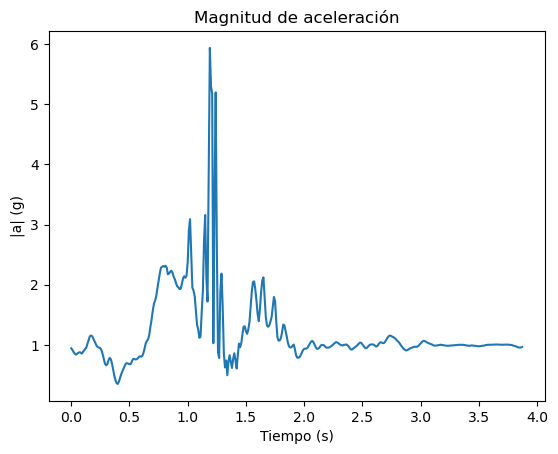

In [410]:
df_s = train_separado["Mariel_02.csv"][4]

acc_mag = np.sqrt(
    df_s["AccX (g)"]**2 +
    df_s["AccY (g)"]**2 +
    df_s["AccZ (g)"]**2
)

plt.plot(df_s["TimeStamp (s)"], acc_mag)
plt.title("Magnitud de aceleración")
plt.xlabel("Tiempo (s)")
plt.ylabel("|a| (g)")
plt.show()

También quiero asegurarme de que el muestreo se haya hecho a 100 Hz, dado que en la exploración el dato de "Norman_02" generó dudas, que posiblemente fueron solo causadas por el desorden de los datos.

In [411]:
len(df_s)
print("Duración:", df_s["TimeStamp (s)"].iloc[-1])
print("Muestras:", len(df_s))
print("Estimado Hz:", len(df_s) / df_s["TimeStamp (s)"].iloc[-1])

Duración: 3.87
Muestras: 385
Estimado Hz: 99.48320413436693


Se confirma el muestreado de los datos a 100 Hz

## Evento de tiro

Al examinar las gráficas de varios datos determiné que no es necesario emplear filtros para limpiar el ruido, en lugar de eso hice un recorte para quedarnos solo con los datos que corresponden a los primeros 3 segundos. El evento de tiro es bastante claro, así que puede ser detectado para luego segmentar en un intervalo adecuado.

A continuación exploraremos el evento de tiro usando el pico de la magnitud de la aceleración. La exploración se hace con el fin de definir la mejor técnica de segmentacion:

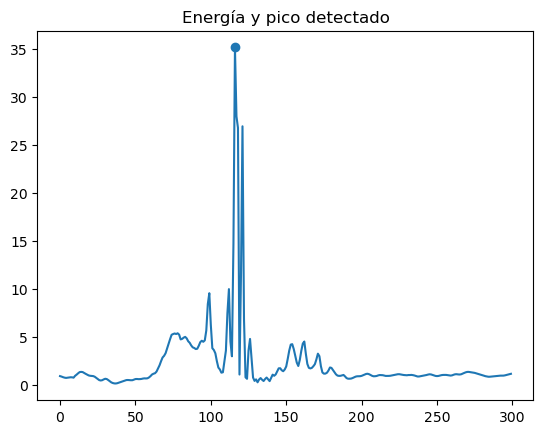

In [412]:
max_samples=300 #Agregó un recorte para quedarnos solo con el tiro
df_s = df_s.iloc[:max_samples].copy()

energy = acc_mag[:max_samples]**2


# Encontrar todos los picos locales
peaks, _ = find_peaks(energy, distance=20)  # separación mínima entre picos

if len(peaks) == 0:
    idx_peak = energy.idxmax()  # fallback
else:
    max_energy = energy.max()
    
    # Filtrar picos suficientemente grandes
    picos_grandes = [p for p in peaks if energy.iloc[p] >= 0.7 * max_energy]
    
    if len(picos_grandes) > 0:
        idx_peak = picos_grandes[0]  # el primero grande
    else:
        idx_peak = energy.iloc[peaks].idxmax()


plt.figure()
plt.plot(energy)
plt.scatter(idx_peak, energy.iloc[idx_peak])
plt.title("Energía y pico detectado")
plt.show()

Ahora segmentaré el evento de tiro definiendo una ventana temporal:

In [413]:
pre  = 60
post = 30

start = max(0, idx_peak - pre)
end   = min(len(df_s), idx_peak + post)

df_segment = df_s.iloc[start:end]

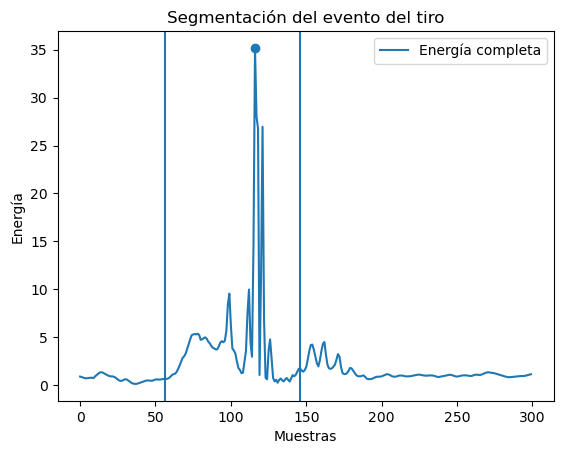

In [414]:
plt.figure()

# Energía completa
plt.plot(energy.values, label="Energía completa")

# Pico
plt.scatter(idx_peak, energy.iloc[idx_peak])

# Límites del segmento
plt.axvline(start)
plt.axvline(end)

plt.title("Segmentación del evento del tiro")
plt.xlabel("Muestras")
plt.ylabel("Energía")
plt.legend()
plt.show()

Observamos un evento del tiro delimitado mediante una ventana temporal. La ventana se sesgo hacia la fase preparatoria, tomando aproximadamente 0.6 s previos al pico de energía y 0.3 s posteriores al mismo. El sesgo se tomo porque consideró que la señal biomecanica puede tener información relevante en la preparación del tiro.

Voy a aplicar la segmentación definida a todo el conjunto de datos de prueba y entrenamiento. La ventana temporal a partir de la detección del pico para cada sensor también servirá para alinear los datos con respecto al evento, por lo cuál ya no será necesario preocuparse por el desfase entre sensores.

In [415]:
def segmentar_sensor(df_s, pre=60, post=30):

    max_samples = 300
    df_s = df_s.iloc[:max_samples].copy()
    
    acc_mag = np.sqrt(
        df_s["AccX (g)"]**2 +
        df_s["AccY (g)"]**2 +
        df_s["AccZ (g)"]**2
    )
    
    energy = acc_mag**2
    
    peaks, _ = find_peaks(energy, distance=20)

    if len(peaks) == 0:
        idx_peak = energy.idxmax()
    else:
        max_energy = energy.max()
        picos_grandes = [p for p in peaks if energy.iloc[p] >= 0.7 * max_energy]
        
        if len(picos_grandes) > 0:
            idx_peak = picos_grandes[0]
        else:
            idx_peak = peaks[np.argmax(energy.iloc[peaks].values)]
    
    start = max(0, idx_peak - pre)
    end   = min(len(df_s), idx_peak + post)
    
    df_segment = df_s.iloc[start:end].reset_index(drop=True)
    
    # índice del pico dentro del segmento
    idx_peak_rel = idx_peak - start
    
    return df_segment, idx_peak_rel

In [416]:
def segmentar_tiro(sensores_dict, pre=60, post=30):
    
    sensores_segmentados = {}
    
    for sid, df_s in sensores_dict.items():
        sensores_segmentados[sid] = segmentar_sensor(df_s, pre, post)
    
    return sensores_segmentados

In [417]:
# Segmentar todos los tiros de entrenamiento y prueba
train_segmentado = {}

for nombre_archivo, sensores in train_separado.items():
    train_segmentado[nombre_archivo] = segmentar_tiro(sensores)

test_segmentado = {}

for nombre_archivo, sensores in test_separado.items():
    test_segmentado[nombre_archivo] = segmentar_tiro(sensores)

(77, 26)


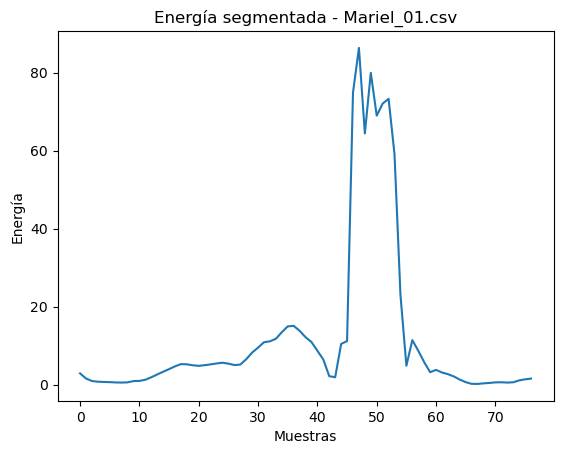

(90, 26)


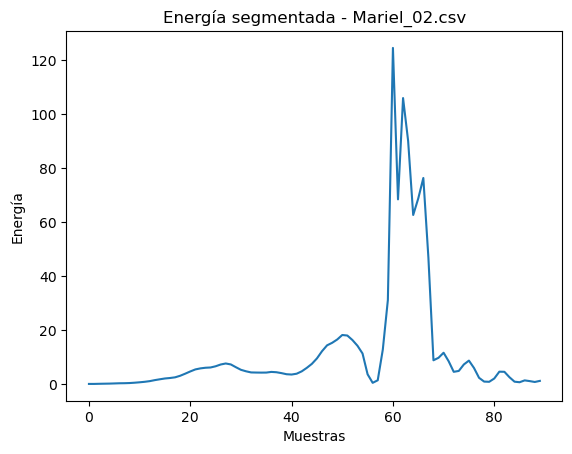

(90, 26)


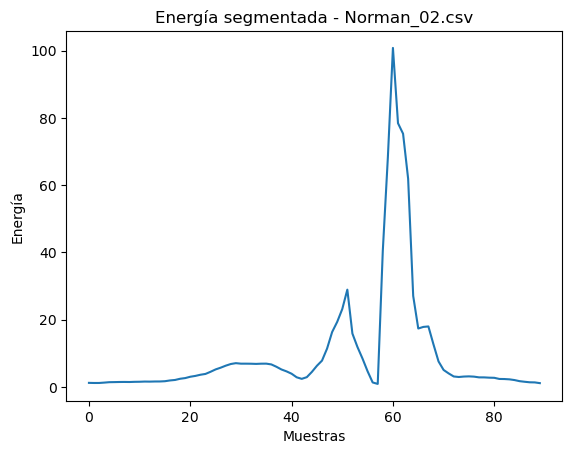

In [418]:
#Verificación de segmentación de tres datos de estudio
for name in ["Mariel_01.csv", "Mariel_02.csv", "Norman_02.csv"]:
    
    df_seg_tuple = train_segmentado[name][2]  # obtiene la tupla
    df_seg = df_seg_tuple[0]  # extrae el DataFrame (primer elemento)
    
    print(df_seg.shape)
    
    acc_mag = np.sqrt(
        df_seg["AccX (g)"]**2 +
        df_seg["AccY (g)"]**2 +
        df_seg["AccZ (g)"]**2
    )
    
    energy_seg = acc_mag**2
    
    plt.figure()
    plt.plot(energy_seg.values)
    plt.title(f"Energía segmentada - {name}")
    plt.xlabel("Muestras")
    plt.ylabel("Energía")
    plt.show()


Ahora trataré de identificar un método consistente para trabajar los ID's mezclados. Evaluando las dinámicas de tiro para ver si hay algún patrón físico

In [419]:
# Verificar energía de tiro\
for name in ["Mariel_02.csv","Norman_02.csv","Javier_03.csv"]:
    print("Tiro:", name)
    sensores = train_separado[name]
    for sid, df_s in sensores.items():
        acc_mag = np.sqrt(
            df_s["AccX (g)"]**2 +
            df_s["AccY (g)"]**2 +
            df_s["AccZ (g)"]**2
        )
        print("  Sensor", sid, "Max acc:", acc_mag.max())

Tiro: Mariel_02.csv
  Sensor 4 Max acc: 5.931514811199266
  Sensor 2 Max acc: 11.163559915229868
  Sensor 5 Max acc: 10.032492574954436
Tiro: Norman_02.csv
  Sensor 4 Max acc: 4.297279276221073
  Sensor 2 Max acc: 10.038460396189102
Tiro: Javier_03.csv
  Sensor 5 Max acc: 7.951604295067553
  Sensor 4 Max acc: 2.799655244246327
  Sensor 2 Max acc: 6.131661685964694


No se ve patrón físico identificable entre sensores usando los datos de aceleración. Evaluaré el giro:

In [420]:
for name in ["Mariel_02.csv","Norman_02.csv","Javier_03.csv"]:
    print("Tiro:", name)
    sensores = train_separado[name]
    
    for sid, df_s in sensores.items():
        gyro_mag = np.sqrt(
            df_s["GyroX (deg/s)"]**2 +
            df_s["GyroY (deg/s)"]**2 +
            df_s["GyroZ (deg/s)"]**2
        )
        print("  Sensor", sid, "Max gyro:", gyro_mag.max())

Tiro: Mariel_02.csv
  Sensor 4 Max gyro: 566.1190374030367
  Sensor 2 Max gyro: 2708.9593406795193
  Sensor 5 Max gyro: 596.0337328936292
Tiro: Norman_02.csv
  Sensor 4 Max gyro: 650.7257589894353
  Sensor 2 Max gyro: 1900.6175797262163
Tiro: Javier_03.csv
  Sensor 5 Max gyro: 599.5532031317559
  Sensor 4 Max gyro: 309.525809069435
  Sensor 2 Max gyro: 847.6160956111727


El sensor 2 es siempre el sensor con mayor rotación. Haré una revisión con los datos de Tony, dado que en su prueba fue que se mezclaron los IDs.

In [421]:
for name in ["Tony_01.csv","Tony_05.csv","Tony_10.csv"]:
    print("Tiro:", name)
    sensores = test_separado[name]
    
    for sid, df_s in sensores.items():
        gyro_mag = np.sqrt(
            df_s["GyroX (deg/s)"]**2 +
            df_s["GyroY (deg/s)"]**2 +
            df_s["GyroZ (deg/s)"]**2
        )
        print("  Sensor", sid, "Max gyro:", gyro_mag.max())

Tiro: Tony_01.csv
  Sensor 1 Max gyro: 591.097391508987
  Sensor 5 Max gyro: 590.7877551067169
  Sensor 2 Max gyro: 1621.0930526681123
Tiro: Tony_05.csv
  Sensor 3 Max gyro: 731.4951846181009
  Sensor 2 Max gyro: 1391.5798246050274
  Sensor 1 Max gyro: 448.0875907042052
Tiro: Tony_10.csv
  Sensor 1 Max gyro: 517.4611694721233
  Sensor 5 Max gyro: 732.1236943398434
  Sensor 2 Max gyro: 1580.9212607371396


Después de observar los datos, concluyó que el sensor con ID 2 presenta consistentemente la mayor energía rotacional en todos los sujetos, lo que sugiere una asignación anatómica estable. Por ello, se mantuvo la estructura basada en los sensores 2, 4 y 5 definidos en el conjunto de entrenamiento. Los otros sensores presentes en el conjunto de prueba se ignorarán.

# Extracción de características

Ahora los datos se han segmentado pasaremos a la extracción de características. La información que se descarta para la extracción de características, por no contener información biomécanica es:

- Pressure
- Temperature
- Altitude
- HeaveMotion
- Magnetómetro

Así pues, sólo se extraerán características de las señales:
- Aceleración
- Gyro 
- Euler

Los cuarteniones no sé eligierón, porque, aunque contienen información biomecánica, su redundancia interna puede ingresar ruido a los modelos que se usarán para la clasificación.

In [422]:
def features_espectrales(signal, fs=100):
    
    # Quitar componente DC
    signal = signal - np.mean(signal)
    
    N = len(signal)
    
    # FFT
    fft_vals = np.fft.rfft(signal)
    fft_freq = np.fft.rfftfreq(N, d=1/fs)
    
    power = np.abs(fft_vals)**2
    
    # Ignorar frecuencia 0
    if len(power) > 1:
        dom_idx = np.argmax(power[1:]) + 1
        dom_freq = fft_freq[dom_idx]
    else:
        dom_freq = 0
    
    total_energy_spec = np.sum(power)
    
    return dom_freq, total_energy_spec

In [445]:
def extraer_features_sensor(df_s, idx_peak):
    df_s = df_s.copy()

    cols_numericas = [
        "AccX (g)", "AccY (g)", "AccZ (g)",
        "GyroX (deg/s)", "GyroY (deg/s)", "GyroZ (deg/s)",
        "EulerZ (deg)"
    ]

    for col in cols_numericas:
        df_s[col] = pd.to_numeric(df_s[col], errors="coerce")

    features = {}
    
    # -------- Aceleración --------
    acc_mag = np.sqrt(
        df_s["AccX (g)"]**2 +
        df_s["AccY (g)"]**2 +
        df_s["AccZ (g)"]**2
    )
    
    features["acc_mean"] = acc_mag.mean()
    features["acc_std"] = acc_mag.std()
    features["acc_max"] = acc_mag.max()
    features["acc_energy"] = np.sum(acc_mag**2)
    features["acc_time_to_peak"] = idx_peak / len(df_s) #ritmo del gesto normalizado
    
    
    # -------- Gyro --------
    gyro_mag = np.sqrt(
        df_s["GyroX (deg/s)"]**2 +
        df_s["GyroY (deg/s)"]**2 +
        df_s["GyroZ (deg/s)"]**2
    )
    
    features["gyro_max"] = gyro_mag.max()
    features["gyro_energy"] = np.sum(gyro_mag**2)
    
    
    # -------- Euler alto nivel --------
    eulerZ = pd.to_numeric(df_s["EulerZ (deg)"], errors="coerce")
    
    if idx_peak > 1:
        features["eulerZ_std_pre"] = eulerZ.iloc[:idx_peak].std()
    else:
        features["eulerZ_std_pre"] = 0
    features["eulerZ_range"] = eulerZ.max() - eulerZ.min()
    features["eulerZ_delta"] = eulerZ.iloc[idx_peak] - eulerZ.iloc[0]
    
    # estabilidad antes del release
    features["eulerZ_std_pre"] = eulerZ.iloc[:idx_peak].std()

    #-------- Espectrales --------
    # -------- Espectral Aceleración --------
    dom_freq_acc, spec_energy_acc = features_espectrales(acc_mag)

    features["acc_dom_freq"] = dom_freq_acc
    features["acc_spec_energy"] = spec_energy_acc

    dom_freq_gyro, spec_energy_gyro = features_espectrales(gyro_mag)

    # -------- Espectral Gyro --------
    features["gyro_dom_freq"] = dom_freq_gyro
    features["gyro_spec_energy"] = spec_energy_gyro
        
    return features

Generación del vector de características por tiro. Se extrajerón 15 características por sensor

In [424]:
# Crear un ejemplo con cualquier sensor válido
ejemplo_sensores = next(iter(train_segmentado.values()))
df_ej, idx_ej = next(iter(ejemplo_sensores.values()))

feats_base = extraer_features_sensor(df_ej, idx_ej)
nombres_base = list(feats_base.keys())

In [425]:
def extraer_features_tiro(sensores_segmentados, sensores_esperados=[2,4,5]):
    
    features_tiro = {}
    
    for sid in sensores_esperados:
        
        if sid in sensores_segmentados:
            
            df_s, idx_peak = sensores_segmentados[sid]
            feats = extraer_features_sensor(df_s, idx_peak)
            
            for k, v in feats.items():
                features_tiro[f"s{sid}_{k}"] = v
        
        else:
            # rellenar con ceros explícitamente
            for k in nombres_base:
                features_tiro[f"s{sid}_{k}"] = 0.0
    
    return features_tiro

In [426]:
X_train_list = []
y_train_list = []
player_ids = []

for _, row in labels.iterrows():
    
    nombre = row["Nombre Archivo"]
    
    if nombre not in train_segmentado:
        continue
    
    clase = row["clase_Tiro"]
    if clase == 2:
        clase = 1
    
    sujeto = row["Sujeto"]
    
    sensores_seg = train_segmentado[nombre]
    feats = extraer_features_tiro(sensores_seg)
    
    X_train_list.append(feats)
    y_train_list.append(clase)
    player_ids.append(sujeto)

X_train = pd.DataFrame(X_train_list)
y_train = np.array(y_train_list)
player_ids = np.array(player_ids)

In [427]:
# Reemplazar inf y NaN por 0
X_train = X_train.replace([np.inf, -np.inf], 0)
X_train = X_train.fillna(0)

In [428]:
print(np.isnan(X_train.values).sum())

0


Se tienen 111 tiros, cada uno con 42 características. Cuando falta un sensor todas las features asociadas a ese sensor se rellenan con 0.0.

In [429]:
np.bincount(y_train)

array([88, 23])

Tenemos
- 88 fallos
- 23 encestes

Un desbalance moderado

# Evaluación Interna

**Escalar datos**

In [430]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

## Logistic Regression

In [431]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, make_scorer

In [432]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

model = LogisticRegression(class_weight="balanced", max_iter=500)
model.fit(X_tr, y_tr)

y_pred = model.predict(X_val)

print(confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred))

[[10  8]
 [ 3  2]]
              precision    recall  f1-score   support

           0       0.77      0.56      0.65        18
           1       0.20      0.40      0.27         5

    accuracy                           0.52        23
   macro avg       0.48      0.48      0.46        23
weighted avg       0.65      0.52      0.56        23



El modelo clasifica correctamente 10 fallos y 2 encestes. Pero clasifica 8 fallos cómo encestes y 3 encestes como fallos.

Evaluando con estratificación cruzada:

In [433]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

f1_scores = cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=skf,
    scoring="f1"
)

print("F1 por fold:", f1_scores)
print("F1 promedio:", f1_scores.mean())

F1 por fold: [0.22222222 0.36363636 0.2        0.         0.16666667]
F1 promedio: 0.19050505050505048


Evaluamos de otra forma. Como quiero que el modelo generalice para jugadores que no están en el conjunto de entrenamiento usaré GroupKFold:

In [434]:
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=8)

scores = cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=gkf,
    groups=player_ids,
    scoring="f1"
)

print("F1 por jugador:", scores)
print("F1 promedio:", scores.mean())

F1 por jugador: [0.         0.125      0.28571429 0.         0.         0.
 0.         0.5       ]
F1 promedio: 0.11383928571428571


El desempeño del modelo baja, quiere decir que el modelo aprende patrones del jugador.

## Random Forest

In [435]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

f1_scores_rf = cross_val_score(
    rf,
    X_train,      
    y_train,
    cv=skf,
    scoring="f1"
)

print("F1 RF por fold:", f1_scores_rf)
print("F1 RF promedio:", f1_scores_rf.mean())


F1 RF por fold: [0. 0. 0. 0. 0.]
F1 RF promedio: 0.0


Random Forest predice todos como fallos. No deteta encestes

Antes de continuar con el ajuste de modelos, se realiza un análisis exploratorio de las características extraídas para verificar si existen diferencias sistemáticas entre tiros encestados y fallidos.

In [436]:
df_analysis = X_train.copy()
df_analysis["label"] = y_train

df_analysis.groupby("label").mean().T.sort_values(by=0)[:10]

label,0,1
s5_eulerZ_delta,-8.424802,-5.911027
s4_acc_time_to_peak,0.142709,0.202899
s4_acc_std,0.229574,0.301455
s4_gyro_dom_freq,0.294791,0.434783
s4_acc_dom_freq,0.321218,0.434783
s4_acc_mean,0.419540,0.559023
s2_acc_time_to_peak,0.423774,0.514578
s5_acc_time_to_peak,0.566908,0.506870
s2_gyro_dom_freq,1.002196,1.224734
s2_acc_dom_freq,1.025691,1.377071


In [437]:
df_analysis.groupby("label").mean().T.sort_values(by=1)[-10:]

label,0,1
s4_acc_spec_energy,8.719577e+02,1.270202e+03
s2_gyro_max,1.554984e+03,1.566878e+03
s5_acc_spec_energy,9.208207e+03,7.356802e+03
s2_acc_spec_energy,1.090713e+04,1.211896e+04
s4_gyro_energy,1.283373e+06,1.976300e+06
s5_gyro_energy,7.779353e+06,5.938911e+06
s2_gyro_energy,2.121331e+07,2.051675e+07
s4_gyro_spec_energy,1.707144e+07,2.539808e+07
s5_gyro_spec_energy,9.555150e+07,6.776065e+07
s2_gyro_spec_energy,4.382565e+08,4.169612e+08


El análisis de las medias por clase muestra que sí existen diferencias entre tiros exitosos y fallidos en algunas características, particularmente en variables relacionadas con la frecuencia dominante, la energía espectral y el tiempo relativo al pico de aceleración.

Sin embargo, estas diferencias no son marcadamente separables, por lo que la discriminación entre clases depende de combinaciones multivariadas de características más que de una única variable dominante.

Esto podría explicar el desempeño limitado de los modelos iniciales, considerandu un escenario con tamaño de muestra reducido y desbalance de clases.

Voy a tratar de afinar *Logistic Regression*

In [438]:
model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    C=0.1  # más regularización
)
model.fit(X_tr, y_tr)

y_pred = model.predict(X_val)

print(confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred))

[[14  4]
 [ 4  1]]
              precision    recall  f1-score   support

           0       0.78      0.78      0.78        18
           1       0.20      0.20      0.20         5

    accuracy                           0.65        23
   macro avg       0.49      0.49      0.49        23
weighted avg       0.65      0.65      0.65        23



Se exploró el efecto de regularización en el modelo de regresión logística. Si bien se observó una ligera mejora en estabilidad general, la capacidad discriminativa sobre la clase minoritaria sigue siendo limitada.

## SVM

In [439]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="linear",
    class_weight="balanced",
    random_state=42
)

f1_svm = cross_val_score(
    svm_model,
    X_train_scaled,
    y_train,
    cv=skf,
    scoring="f1"
)

print("F1 SVM por fold:", f1_svm)
print("F1 SVM promedio:", f1_svm.mean())

F1 SVM por fold: [0.16666667 0.33333333 0.2        0.         0.16666667]
F1 SVM promedio: 0.1733333333333333


Trataré de afinar SVM

In [440]:

for C_val in [0.01, 0.1, 1, 5, 10]:
    
    svm_model = SVC(
        kernel="linear",
        C=C_val,
        class_weight="balanced",
        random_state=42
    )
    
    f1_svm = cross_val_score(
        svm_model,
        X_train_scaled,
        y_train,
        cv=skf,
        scoring="f1"
    )
    
    print(f"C={C_val} → F1 promedio:", f1_svm.mean())

C=0.01 → F1 promedio: 0.2671428571428571
C=0.1 → F1 promedio: 0.18761904761904763
C=1 → F1 promedio: 0.1733333333333333
C=5 → F1 promedio: 0.2250678733031674
C=10 → F1 promedio: 0.2393939393939394


Se observó que la SVM lineal presentó su mejor desempeño con un valor bajo del parámetro C (C = 0.01), quiere decir que una mayor regularización favorece la generalización en este conjunto de datos.

In [441]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report

svm_final = SVC(
    kernel="linear",
    C=0.01,
    class_weight="balanced",
    random_state=42
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Predicciones usando validación cruzada
y_pred_cv = cross_val_predict(
    svm_final,
    X_train_scaled,
    y_train,
    cv=skf
)

print("Matriz de confusión:")
print(confusion_matrix(y_train, y_pred_cv))

print("\nReporte de clasificación:")
print(classification_report(y_train, y_pred_cv))

Matriz de confusión:
[[66 22]
 [16  7]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.80      0.75      0.78        88
           1       0.24      0.30      0.27        23

    accuracy                           0.66       111
   macro avg       0.52      0.53      0.52       111
weighted avg       0.69      0.66      0.67       111



El mejor desempeño se obtuvo con una SVM lineal con fuerte regularización (C=0.01), alcanzando un F1-score promedio de 0.27 bajo validación cruzada estratificada. La matriz de confusión indica que el modelo logra identificar parcialmente la clase minoritaria (encestes), aunque con limitada precisión,

## KNN

In [442]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

f1_knn = cross_val_score(
    knn_model,
    X_train_scaled,
    y_train,
    cv=skf,
    scoring="f1"
)

print("F1 KNN por fold:", f1_knn)
print("F1 KNN promedio:", f1_knn.mean())

F1 KNN por fold: [0. 0. 0. 0. 0.]
F1 KNN promedio: 0.0


## Gradient Boosting

In [443]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)

f1_gb = cross_val_score(
    gb_model,
    X_train,
    y_train,
    cv=skf,
    scoring="f1"
)

print("F1 GB por fold:", f1_gb)
print("F1 GB promedio:", f1_gb.mean())

F1 GB por fold: [0.         0.         0.33333333 0.         0.4       ]
F1 GB promedio: 0.14666666666666667


# Test de prueba

Se emplea el modelo SVM con C=0.001 para el test de prueba.

Entrenar el modelo:

In [448]:
from sklearn.svm import SVC

svm_final = SVC(
    kernel="linear",
    C=0.01,
    class_weight="balanced",
    random_state=42
)

svm_final.fit(X_train_scaled, y_train)

SVC(C=0.01, class_weight='balanced', kernel='linear', random_state=42)

Extraer características:

In [452]:
X_test_list = []
test_names = []

for nombre, sensores_seg in test_segmentado.items():
    
    feats = extraer_features_tiro(sensores_seg)
    
    X_test_list.append(feats)
    test_names.append(nombre)

X_test = pd.DataFrame(X_test_list)

# MUY IMPORTANTE: mismo orden de columnas que train
X_test = X_test[X_train.columns]

print("X_test shape:", X_test.shape)

X_test shape: (30, 42)


Escalar:

In [453]:
X_test_scaled = scaler.transform(X_test)

Predecir:

In [454]:
y_test_pred = svm_final.predict(X_test_scaled)

Generar archivo:

In [455]:
submission = pd.DataFrame({
    "nombre": test_names,
    "pred": y_test_pred
})

submission.to_csv("predicciones_PR3.csv", index=False)

submission

,nombre,pred
0,Joan_01.csv,0
1,Joan_02.csv,0
2,Joan_03.csv,1
3,Joan_04.csv,0
4,Joan_05.csv,0
5,Joan_06.csv,0
6,Joan_07.csv,0
7,Joan_08.csv,0
8,Joan_09.csv,0
9,Joan_10.csv,0


# Pipeline de Inferencia

In [456]:
import joblib

joblib.dump(svm_final, "modelo_svm_PR3.pkl")
joblib.dump(scaler, "scaler_PR3.pkl")

print("Modelo y scaler guardados correctamente.")

Modelo y scaler guardados correctamente.


In [465]:
def preprocesar_y_predecir(nombre_archivo):

    # Usar el mismo diccionario ya segmentado
    sensores_segmentados = test_segmentado[nombre_archivo]

    feats = extraer_features_tiro(sensores_segmentados)

    X = pd.DataFrame([feats])
    X = X.reindex(columns=X_train.columns, fill_value=0)

    X_scaled = scaler.transform(X)

    pred = svm_final.predict(X_scaled)

    return pred[0]

In [466]:
pred = preprocesar_y_predecir("Joan_01.csv")
print("Predicción:", pred)

Predicción: 0


# Conclusión

En esta práctica se desarrolló un pipeline completo de clasificación de lanzamientos de baloncesto a partir de señales inerciales capturadas con tres IMUs.

Se implementó segmentación basada en energía para aislar el evento del tiro, extracción de características estadísticas, temporales y espectrales, así como variables de alto nivel basadas en ángulos de Euler.

Se evaluaron cinco modelos de clasificación bajo validación cruzada estratificada, obteniendo el mejor desempeño con una SVM lineal fuertemente regularizada (C=0.01), alcanzando un F1-score promedio aproximado de 0.27.

El bajo desempeño general sugiere que las diferencias biomecánicas entre encestes y fallos son sutiles en este conjunto de datos, y que el tamaño limitado del dataset restringe la capacidad de generalización del modelo.

Además, durante la validación externa se observó que el modelo predice encestes para el sujeto Tony, quien recuerdo que no registró aciertos durante la adquisición de los datos. Esto puede atribuirse a:

- Desbalance significativo de clases.

- Pérdida parcial de sensores en algunos tiros.

- Posibles inconsistencias en la configuración de IDs de sensores. Sobretodo en el sujeto Tony

- Variabilidad inter-sujeto no modelada explícitamente.

Estos factores limitan la robustez del clasificador y evidencian la importancia de una adquisición de datos más controlada y consistente para aplicaciones biomecánicas de este tipo.

En general, el ejercicio permitió integrar procesamiento de señales, ingeniería de características y evaluación de modelos supervisados en un entorno experimental real, evidenciando tanto el potencial como las limitaciones del enfoque propuesto.